Python Setup

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)

customer_file_path = os.path.join(project_root, 'Data', 'raw', 'Olist_ecom_data', 'olist_customers_dataset.csv')

customer = pd.read_csv(customer_file_path)

In [2]:
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


Unique vs Repeat Customers

In [4]:
print(f"Total rows: {len(customer)}")
print(f"Unique customer_id: {customer['customer_id'].nunique()}")
print(f"Unique customer_unique_id: {customer['customer_unique_id'].nunique()}")

Total rows: 99441
Unique customer_id: 99441
Unique customer_unique_id: 96096


In [ ]:
# Total orders
total_orders = len(customer)

# Unique customers
unique_customers = customer['customer_unique_id'].nunique()

# Repeat customers
repeat_customers = total_orders - unique_customers

# Repeat rate
repeat_rate = (repeat_customers / total_orders) * 100

print(repeat_rate) 

# Repeat Rate: 3.36%
# Only 3.36% of customers ordered more than once
# 96.64% of customers are ONE-TIME buyers

3.3638036624732255


In [8]:
customer.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Geographic Distribution

In [11]:
# Top 10 states by customer count
top_states = customer['customer_state'].value_counts().head(10).reset_index()
top_states.columns = ['state', 'count']
print(top_states)

  state  count
0    SP  41746
1    RJ  12852
2    MG  11635
3    RS   5466
4    PR   5045
5    SC   3637
6    BA   3380
7    DF   2140
8    ES   2033
9    GO   2020


C:\Users\phone\AppData\Local\Temp\ipykernel_7772\3926747316.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_states, x='count', y='state', palette='magma')


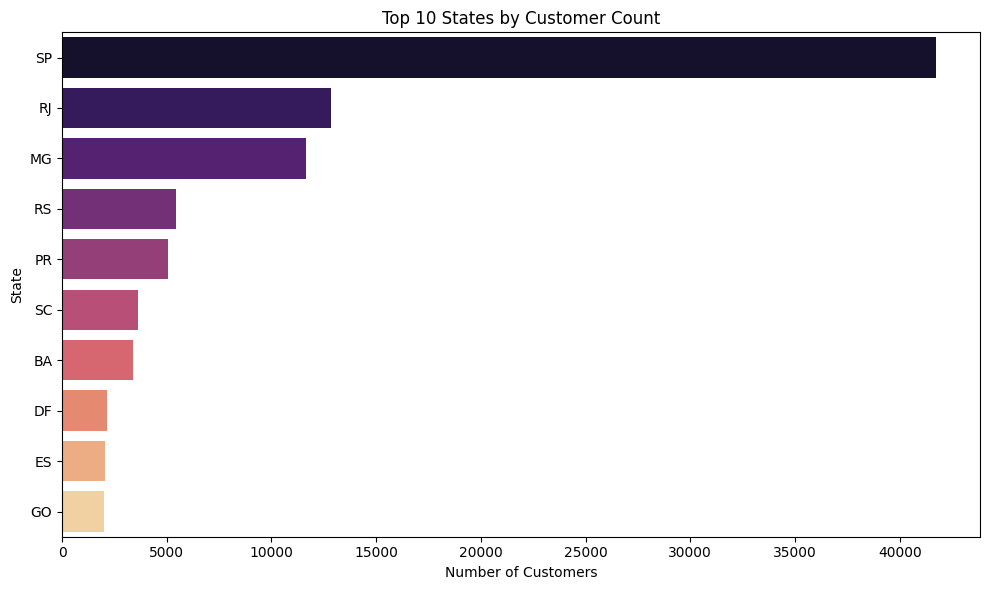

In [ ]:
# Visualize the top states

plt.figure(figsize=(10, 6))
sns.barplot(data=top_states, x='count', y='state', palette='magma')
plt.title('Top 10 States by Customer Count')
plt.xlabel('Number of Customers')
plt.ylabel('State')
plt.tight_layout()
plt.show()

In [10]:
# Top 10 cities by customer count
top_cities = customer['customer_city'].value_counts().head(10).reset_index()
top_cities.columns = ['city', 'count']

print(top_cities)

                    city  count
0              sao paulo  15540
1         rio de janeiro   6882
2         belo horizonte   2773
3               brasilia   2131
4               curitiba   1521
5               campinas   1444
6           porto alegre   1379
7               salvador   1245
8              guarulhos   1189
9  sao bernardo do campo    938


C:\Users\phone\AppData\Local\Temp\ipykernel_7772\3367434813.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cities, x='count', y='city', palette='magma')


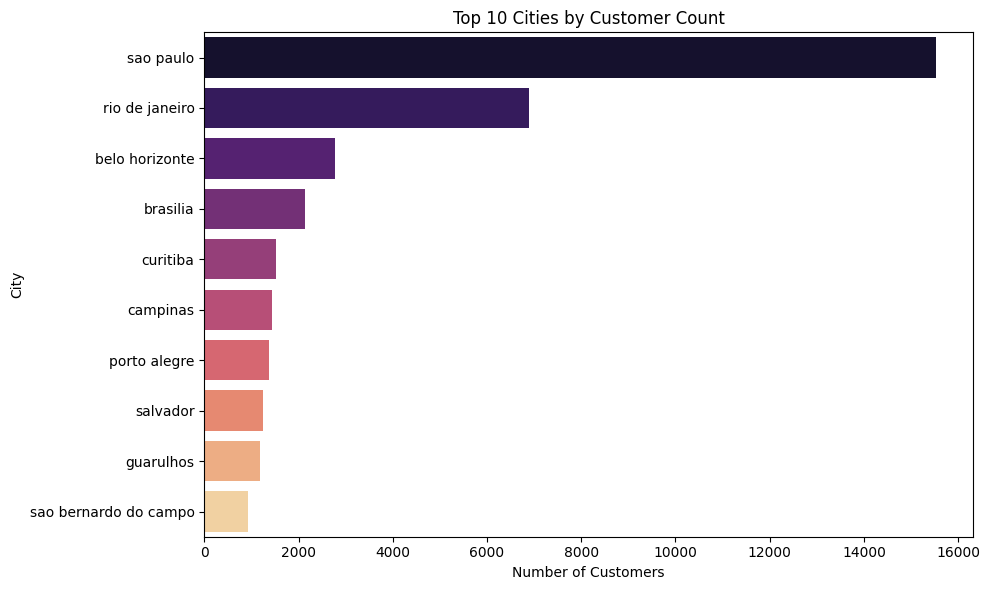

In [12]:
# Visualize the top cities
plt.figure(figsize=(10, 6))
sns.barplot(data=top_cities, x='count', y='city', palette='magma')
plt.title('Top 10 Cities by Customer Count')
plt.xlabel('Number of Customers')
plt.ylabel('City')
plt.tight_layout()
plt.show()

Concentration KPI 

In [13]:
# What % of customers come from top 3 states?
total_customers = len(customer)
top3_states_count = customer['customer_state'].value_counts().head(3).sum()
top3_concentration = (top3_states_count / total_customers) * 100

print(f"Total Customers:        {total_customers}")
print(f"Top 3 States Customers: {top3_states_count}")
print(f"Top 3 Concentration:    {top3_concentration:.2f}%")

Total Customers:        99441
Top 3 States Customers: 66233
Top 3 Concentration:    66.61%


In [14]:
# Average customers per state
avg_per_state = customer['customer_state'].value_counts().mean()
print(f"Avg Customers per State: {avg_per_state:.0f}")

Avg Customers per State: 3683


In [15]:
avg_per_city = customer['customer_city'].value_counts().mean()
print(f"Avg Customers per City: {avg_per_city:.0f}")

Avg Customers per City: 24


In [16]:
# States with less than average customers
state_counts = customer['customer_state'].value_counts()
underserved = state_counts[state_counts < state_counts.mean()]
print(f"Underserved States: {len(underserved)} out of {len(state_counts)}")

Underserved States: 22 out of 27


In [17]:
# How many unique cities and states?
print(f"Unique States: {customer['customer_state'].nunique()}")
print(f"Unique Cities: {customer['customer_city'].nunique()}")

Unique States: 27
Unique Cities: 4119


In [18]:
# SP alone vs rest of Brazil
sp_share = (customer[customer['customer_state'] == 'SP'].shape[0] / len(customer)) * 100
print(f"SP Market Share: {sp_share:.2f}%")

SP Market Share: 41.98%


In [19]:
# Which city dominates each state?
top_city_per_state = customer.groupby('customer_state').apply(
    lambda x: x['customer_city'].value_counts().index[0]
).reset_index()
top_city_per_state.columns = ['state', 'top_city']
print(top_city_per_state)

   state        top_city
0     AC      rio branco
1     AL          maceio
2     AM          manaus
3     AP          macapa
4     BA        salvador
5     CE       fortaleza
6     DF        brasilia
7     ES         vitoria
8     GO         goiania
9     MA        sao luis
10    MG  belo horizonte
11    MS    campo grande
12    MT          cuiaba
13    PA           belem
14    PB     joao pessoa
15    PE          recife
16    PI        teresina
17    PR        curitiba
18    RJ  rio de janeiro
19    RN           natal
20    RO     porto velho
21    RR       boa vista
22    RS    porto alegre
23    SC   florianopolis
24    SE         aracaju
25    SP       sao paulo
26    TO          palmas
